In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white', 'axes.facecolor': 'white'})

PRIMARY = '#2E5EAA'
NOSHOW_COLOR = '#D64550'
ATTEND_COLOR = '#2E8B57'
CANCEL_COLOR = '#C9A227'
PALETTE = {'Attended': ATTEND_COLOR, 'No-Show': NOSHOW_COLOR, 'Cancelled': CANCEL_COLOR}


df = pd.read_csv(r"C:\Users\adeyi\Downloads\HealthConnect_Appointment_Data.csv")
print (f"Rows:{df.shape[0]}, Columns:{df.shape[1]}")
df.head()


Rows:5000, Columns:18


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [3]:
missing = df.isnull().sum()
missing_pct = (missing/len(df) * 100).round(2)
pd.DataFrame({'Missing_count': missing, 'missing_pct': missing_pct})[missing > 0].sort_values('missing_pct', ascending=False)


,Missing_count,missing_pct
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


**Observation:** three columns contain missing values:
- `reminder_channel` — 1,366 missing. This is **structural, not an error**: every one of these rows has `reminder_sent = 'No'`, i.e. no channel exists because no reminder was sent (verified below).
- `distance_to_clinic_km` — 90 missing (1.8%).
- `waiting_time_minutes` — 60 missing (1.2%).

The two decimal fields have a small proportion of genuinely missing values (likely unrecorded at the point of check-in) and are left as `NaN` rather than imputed, since imputing could bias the distance/waiting-time analysis below. Rows are only excluded row-wise for the specific calculation that needs the missing field.

In [4]:
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate appointment_id:", df['appointment_id'].duplicated().sum())
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(20))

Duplicate Rows: 0
Duplicate appointment_id: 0

appointment_id:
appointment_id
HC-05000    1
HC-00001    1
HC-00002    1
HC-00003    1
HC-00004    1
HC-00005    1
HC-00006    1
HC-00007    1
HC-04961    1
HC-04962    1
HC-04963    1
HC-04964    1
HC-04965    1
HC-04966    1
HC-04967    1
HC-04968    1
HC-04953    1
HC-04954    1
HC-04955    1
HC-04956    1
Name: count, dtype: int64

patient_id:
patient_id
P-1399    9
P-1776    9
P-1742    9
P-0599    8
P-0887    8
P-0869    8
P-0252    8
P-0780    8
P-1104    8
P-0453    7
P-0911    7
P-0195    7
P-0912    7
P-1793    7
P-0694    7
P-0548    7
P-0586    7
P-1273    7
P-0818    7
P-0787    7
Name: count, dtype: int64

gender:
gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

age_group:
age_group
65+      1241
35-44     819
55-64     800
45-54     793
25-34     783
18-24     564
Name: count, dtype: int64

appointment_type:
appointment_type
General Consultation       2086
Follow

**Observation:** no duplicate rows and no duplicate `appointment_id` values — the primary key is intact.

In [5]:
df["booking_date"] = pd.to_datetime(df["booking_date"], errors="coerce")
df["appointment_date"] = pd.to_datetime(df["appointment_date"], errors="coerce")
df["reminder_channel"] = df["reminder_channel"].fillna("Not Recorded")

df["lead_time_band"] = pd.cut(
    df["booking_lead_days"], [-1, 7, 14, 30, 45, 60],
    labels=["0–7", "8–14", "15–30", "31–45", "46–60"]
)
df["distance_band"] = pd.cut(
    df["distance_to_clinic_km"], [-1, 5, 10, 20, 999],
    labels=["0–5 km", "5.1–10 km", "10.1–20 km", "20+ km"]
)
df["wait_band"] = pd.cut(
    df["waiting_time_minutes"], [-1, 15, 30, 45, 999],
    labels=["0–15 min", "16–30 min", "31–45 min", "46+ min"]
)

display(df.head())

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,lead_time_band,distance_band,wait_band
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,...,2,0,Yes,WhatsApp,19.3,29.0,No-Show,8–14,10.1–20 km,16–30 min
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,...,6,0,Yes,SMS,14.3,42.0,Attended,0–7,10.1–20 km,31–45 min
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,...,5,1,Yes,SMS,11.4,11.0,No-Show,31–45,10.1–20 km,0–15 min
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,...,3,1,Yes,SMS,7.4,35.0,Attended,31–45,5.1–10 km,31–45 min
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,...,3,1,Yes,Email,5.6,27.0,No-Show,46–60,5.1–10 km,16–30 min


### Data-quality observations
- 5,000 appointment records and 18 original variables were supplied.
- No duplicate rows were found.
- `reminder_channel` contains 1,366 missing values; these were retained analytically as **Not Recorded** rather than inventing a channel.
- `distance_to_clinic_km` has 90 missing values (1.8%).
- `waiting_time_minutes` has 60 missing values (1.2%).
- Booking and appointment dates were converted to datetime.
- No original records were overwritten; derived fields are saved separately.

In [6]:
df['appointment_day'].value_counts()

appointment_day
Wednesday    737
Sunday       737
Friday       728
Saturday     724
Monday       701
Tuesday      689
Thursday     684
Name: count, dtype: int64

In [7]:
total = len(df)
attended = df["appointment_outcome"].eq("Attended").sum()
no_show = df["appointment_outcome"].eq("No-Show").sum()
cancelled = df["appointment_outcome"].eq("Cancelled").sum()

kpis = pd.DataFrame({
    "KPI": ["Total appointments", "Attendance rate", "No-show rate", "Cancellation rate", "No-show rate among non-cancelled"],
    "Value": [
        total,
        attended / total * 100,
        no_show / total * 100,
        cancelled / total * 100,
        no_show / (no_show + attended) * 100
    ]
})
kpis

,KPI,Value
0,Total appointments,5000.000000
1,Attendance rate,46.280000
2,No-show rate,48.460000
3,Cancellation rate,5.260000
4,No-show rate among non-cancelled,51.150517


appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

appointment_outcome
No-Show      48.46
Attended     46.28
Cancelled     5.26
Name: proportion, dtype: float64


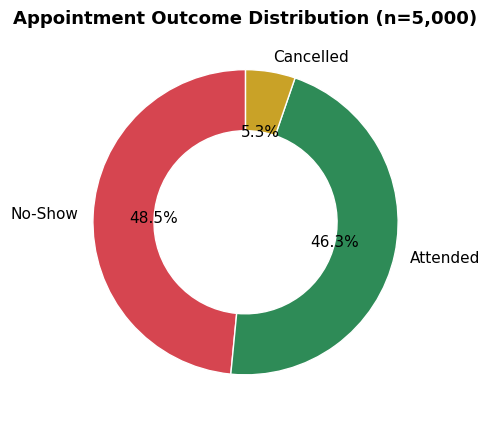

In [8]:
# Overall outcome distribution
counts = df['appointment_outcome'].value_counts()
pct = df['appointment_outcome'].value_counts(normalize=True).mul(100).round(2)
print(counts); print(); print(pct)

fig, ax = plt.subplots(figsize=(5,5))
colors = [PALETTE[c] for c in counts.index]
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90,
       wedgeprops=dict(width=0.4, edgecolor='white'))
ax.set_title('Appointment Outcome Distribution (n=5,000)', fontsize=13, fontweight='bold')
plt.tight_layout();
plt.savefig("appointment distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** almost half of all scheduled appointments (48.5%) end in a **No-Show**, slightly more than the 46.3% that are Attended, with 5.3% Cancelled in advance. Missed appointments are HealthConnect's single largest attendance problem — larger than attendance itself.

lead_bucket
0-3      24.84
4-7      30.75
8-14     33.55
15-30    43.21
31-60    60.49
Name: appointment_outcome, dtype: float64


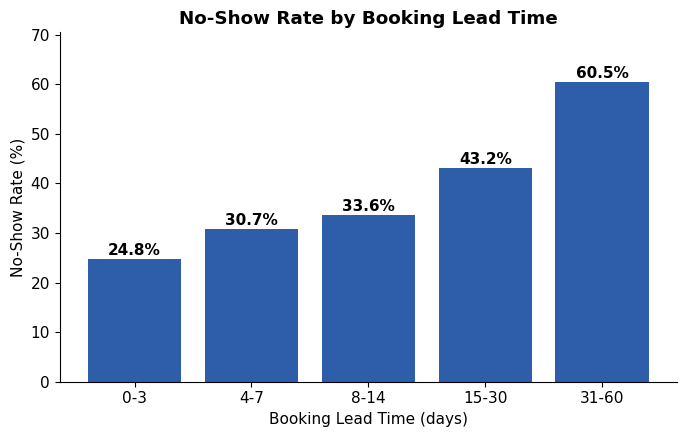

In [9]:
# No-show rate by booking lead time
df['lead_bucket'] = pd.cut(df['booking_lead_days'], bins=[-1,3,7,14,30,60],
                            labels=['0-3','4-7','8-14','15-30','31-60'])
rates = df.groupby('lead_bucket', observed=True)['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100)
print(rates.round(2))

fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(rates.index.astype(str), rates.values, color=PRIMARY)
for b, v in zip(bars, rates.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_xlabel('Booking Lead Time (days)'); ax.set_ylabel('No-Show Rate (%)')
ax.set_title('No-Show Rate by Booking Lead Time', fontweight='bold')
ax.set_ylim(0, max(rates.values)+10); ax.spines[['top','right']].set_visible(False)
plt.tight_layout();
plt.savefig('no_shows_by_booking_time_.png', dpi=300, bbox_inches='tight')

plt.show()

**Observation:** this is the strongest relationship in the dataset. No-show rate rises from **24.8%** for appointments booked 0–3 days ahead to **60.5%** for appointments booked 31–60 days ahead — a 35.6 percentage-point gap. The longer a patient waits between booking and their appointment, the more likely they are to forget or lose the motivation to attend.

distance_bucket
0-5      46.45
5-10     46.51
10-20    49.43
20-30    55.45
30-50    68.06
Name: appointment_outcome, dtype: float64


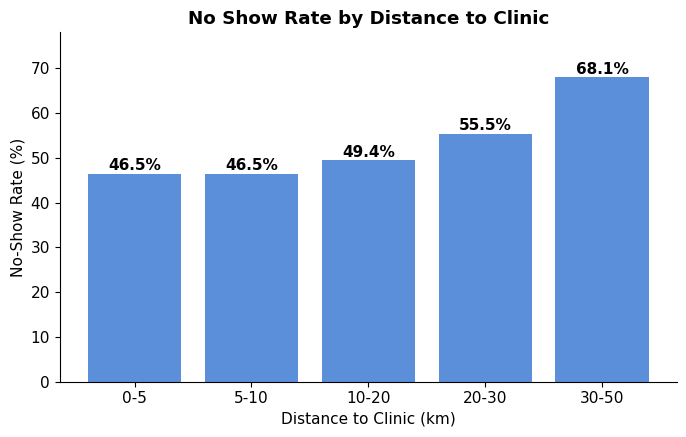

In [10]:
# No-show rate by distance to clinic
df['distance_bucket'] = pd.cut(df['distance_to_clinic_km'], bins=[0,5,10,20,30,50],
                                labels=['0-5','5-10','10-20','20-30','30-50'])
rates = df.groupby('distance_bucket', observed=True)['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100)
print(rates.round(2))

fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(rates.index.astype(str), rates.values, color='#5B8FD9')
for b, v in zip(bars, rates.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_xlabel('Distance to Clinic (km)'); ax.set_ylabel('No-Show Rate (%)')
ax.set_title('No Show Rate by Distance to Clinic', fontweight='bold')
ax.set_ylim(0, max(rates.values)+10); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); 
plt.savefig('no_shows_by_distance_to_clinic.png', dpi=300, bbox_inches='tight')

plt.show()

**Observation:** no-show rate climbs from 46.5% for patients within 5km to **68.1%** for patients 30–50km away. Travel distance is a real barrier to attendance, independent of reminders.

prev_noshow_bucket
0     43.51
1     53.49
2     59.36
3+    68.82
Name: appointment_outcome, dtype: float64


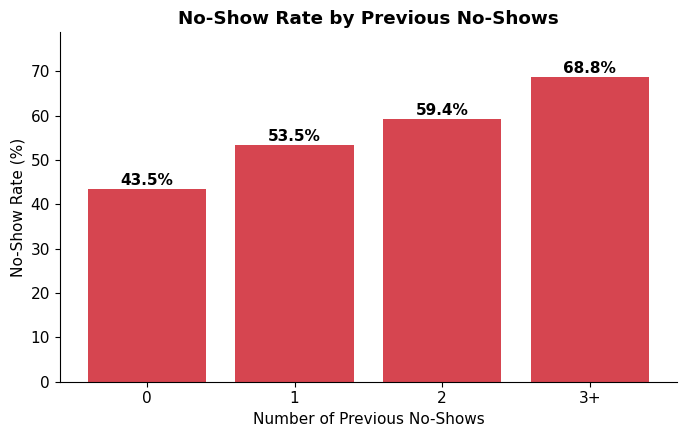

In [11]:
# No-show rate by prior no-show history
df['prev_noshow_bucket'] = pd.cut(df['previous_no_shows'], bins=[-1,0,1,2,10], labels=['0','1','2','3+'])
rates = df.groupby('prev_noshow_bucket', observed=True)['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100)
print(rates.round(2))

fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(rates.index.astype(str), rates.values, color=NOSHOW_COLOR)
for b, v in zip(bars, rates.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_xlabel('Number of Previous No-Shows'); ax.set_ylabel('No-Show Rate (%)')
ax.set_title('No-Show Rate by Previous No-Shows', fontweight='bold')
ax.set_ylim(0, max(rates.values)+10); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); 
plt.savefig('no_shows_by_previous_no_shows.png', dpi=300, bbox_inches='tight')

plt.show()


**Observation:** patients with 3+ prior no-shows miss **68.8%** of appointments, versus 43.5% for patients with no prior no-shows. Attendance history is a strong, readily-available signal for identifying at-risk patients before they even book — this is directly useful input for the Data Science track's predictive model.

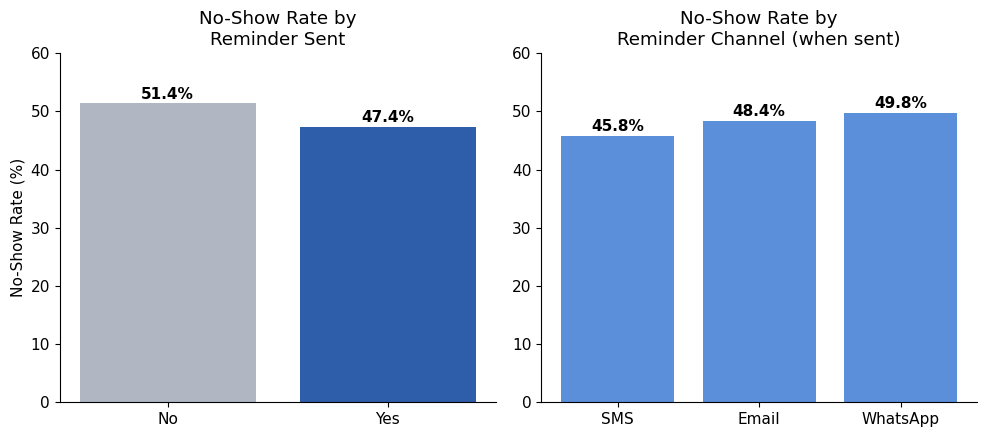

reminder_sent
No     51.39
Yes    47.36
Name: appointment_outcome, dtype: float64

reminder_channel
SMS         45.75
Email       48.41
WhatsApp    49.77
Name: appointment_outcome, dtype: float64


In [12]:
# No-show rate by reminders (sent vs channel)
fig, axes = plt.subplots(1, 2, figsize=(10,4.5))

r1 = df.groupby('reminder_sent')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100)
bars = axes[0].bar(r1.index, r1.values, color=['#B0B7C3', PRIMARY])
for b, v in zip(bars, r1.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('No-Show Rate by\nReminder Sent'); axes[0].set_ylabel('No-Show Rate (%)')
axes[0].set_ylim(0,60); axes[0].spines[['top','right']].set_visible(False)

r2 = df[df['reminder_sent']=='Yes'].groupby('reminder_channel')['appointment_outcome']\
        .apply(lambda x: (x=='No-Show').mean()*100).sort_values()
bars = axes[1].bar(r2.index, r2.values, color='#5B8FD9')
for b, v in zip(bars, r2.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('No-Show Rate by\nReminder Channel (when sent)')
axes[1].set_ylim(0,60); axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); 
plt.savefig('no_shows_by_reminder.png', dpi=300, bbox_inches='tight')

plt.show()

print(r1.round(2)); print(); print(r2.round(2))

**Observation:** sending a reminder reduces no-shows from 51.4% to 47.4% (a 4.0 percentage-point improvement) — real, but modest compared to the lead-time and distance effects above. Among channels, **SMS performs best** (45.8%), followed by Email (48.4%) and WhatsApp (49.8%).

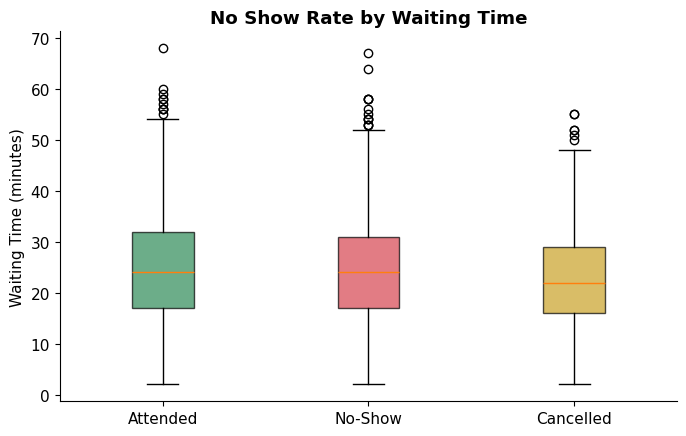

appointment_outcome
Attended     24.3
Cancelled    23.2
No-Show      24.2
Name: waiting_time_minutes, dtype: float64

In [13]:
# Waiting time by outcome
fig, ax = plt.subplots(figsize=(7,4.5))
data = [df[df['appointment_outcome']==o]['waiting_time_minutes'].dropna() for o in ['Attended','No-Show','Cancelled']]
bp = ax.boxplot(data, tick_labels=['Attended','No-Show','Cancelled'], patch_artist=True)
for patch, o in zip(bp['boxes'], ['Attended','No-Show','Cancelled']):
    patch.set_facecolor(PALETTE[o]); patch.set_alpha(0.7)
ax.set_ylabel('Waiting Time (minutes)')
ax.set_title('No Show Rate by Waiting Time', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('no_shows_by_waiting_time.png', dpi=300, bbox_inches='tight')

plt.show()

df.groupby('appointment_outcome')['waiting_time_minutes'].mean().round(1)

**Observation:** average waiting time is almost identical across Attended (24.3 min), No-Show (24.2 min) and Cancelled (23.2 min) appointments. Waiting time — as recorded here — is **not** a driver of no-shows; it looks more like an operational quality metric in its own right, worth tracking, but not for attendance prediction.

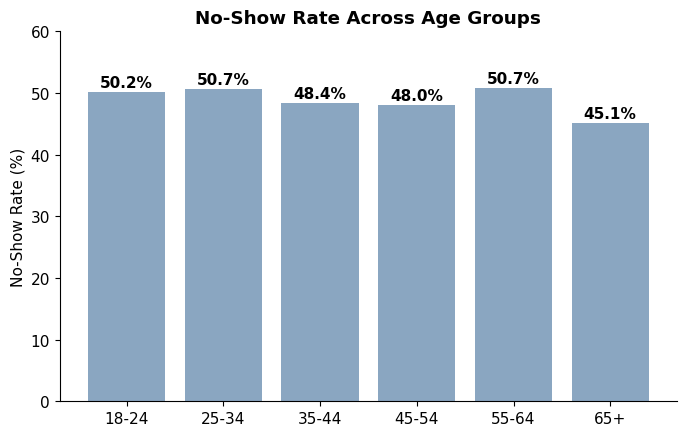

In [14]:
rates = df.groupby('age_group')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100)
order = ['18-24','25-34','35-44','45-54','55-64','65+']
rates = rates.reindex(order)

fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(rates.index, rates.values, color='#8AA6C1')
for b, v in zip(bars, rates.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('No-Show Rate (%)')
ax.set_title('No-Show Rate Across Age Groups', fontweight='bold')
ax.set_ylim(0,60); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('no_shows_by_age group.png', dpi=300, bbox_inches='tight')

plt.show()


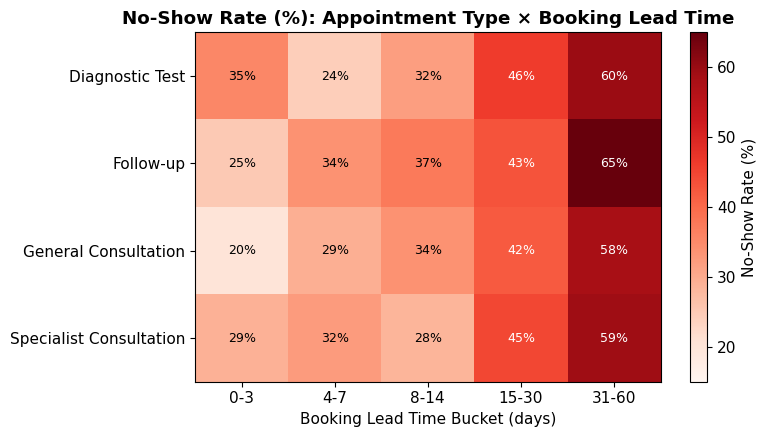

In [15]:
# Combined view: appointment type x lead time (heatmap)
pivot = df.pivot_table(index='appointment_type', columns='lead_bucket', values='appointment_outcome',
                        aggfunc=lambda x: (x=='No-Show').mean()*100, observed=True)
fig, ax = plt.subplots(figsize=(8,4.5))
im = ax.imshow(pivot.values, cmap='Reds', aspect='auto', vmin=15, vmax=65)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', color='white' if val > 40 else 'black', fontsize=9)
ax.set_xlabel('Booking Lead Time Bucket (days)')
ax.set_title('No-Show Rate (%): Appointment Type × Booking Lead Time', fontweight='bold')
plt.colorbar(im, ax=ax, label='No-Show Rate (%)')
plt.tight_layout();
plt.savefig('no_shows_by_appointment_typeXbooking_time.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** the lead-time effect holds **consistently across every appointment type** — confirming it is a genuine attendance driver rather than an artefact of one specific service line.

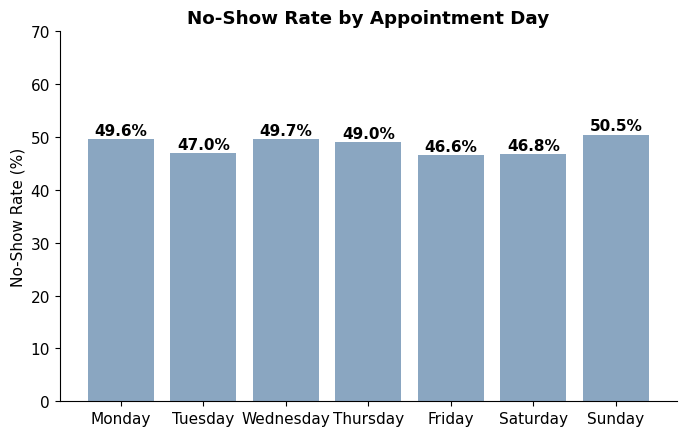

In [16]:
rates = df.groupby('appointment_day')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100)
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
rates = rates.reindex(order)

fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(rates.index, rates.values, color='#8AA6C1')
for b, v in zip(bars, rates.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('No-Show Rate (%)')
ax.set_title('No-Show Rate by Appointment Day', fontweight='bold')
ax.set_ylim(0,70); ax.spines[['top','right']].set_visible(False)
plt.tight_layout();plt.savefig('no_shows_by_appointment_day.png', dpi=300, bbox_inches='tight')

plt.show()

##  Analytical Dashboard Summary

The chart below consolidates the four strongest attendance drivers identified above into a single at-a-glance view for stakeholders.

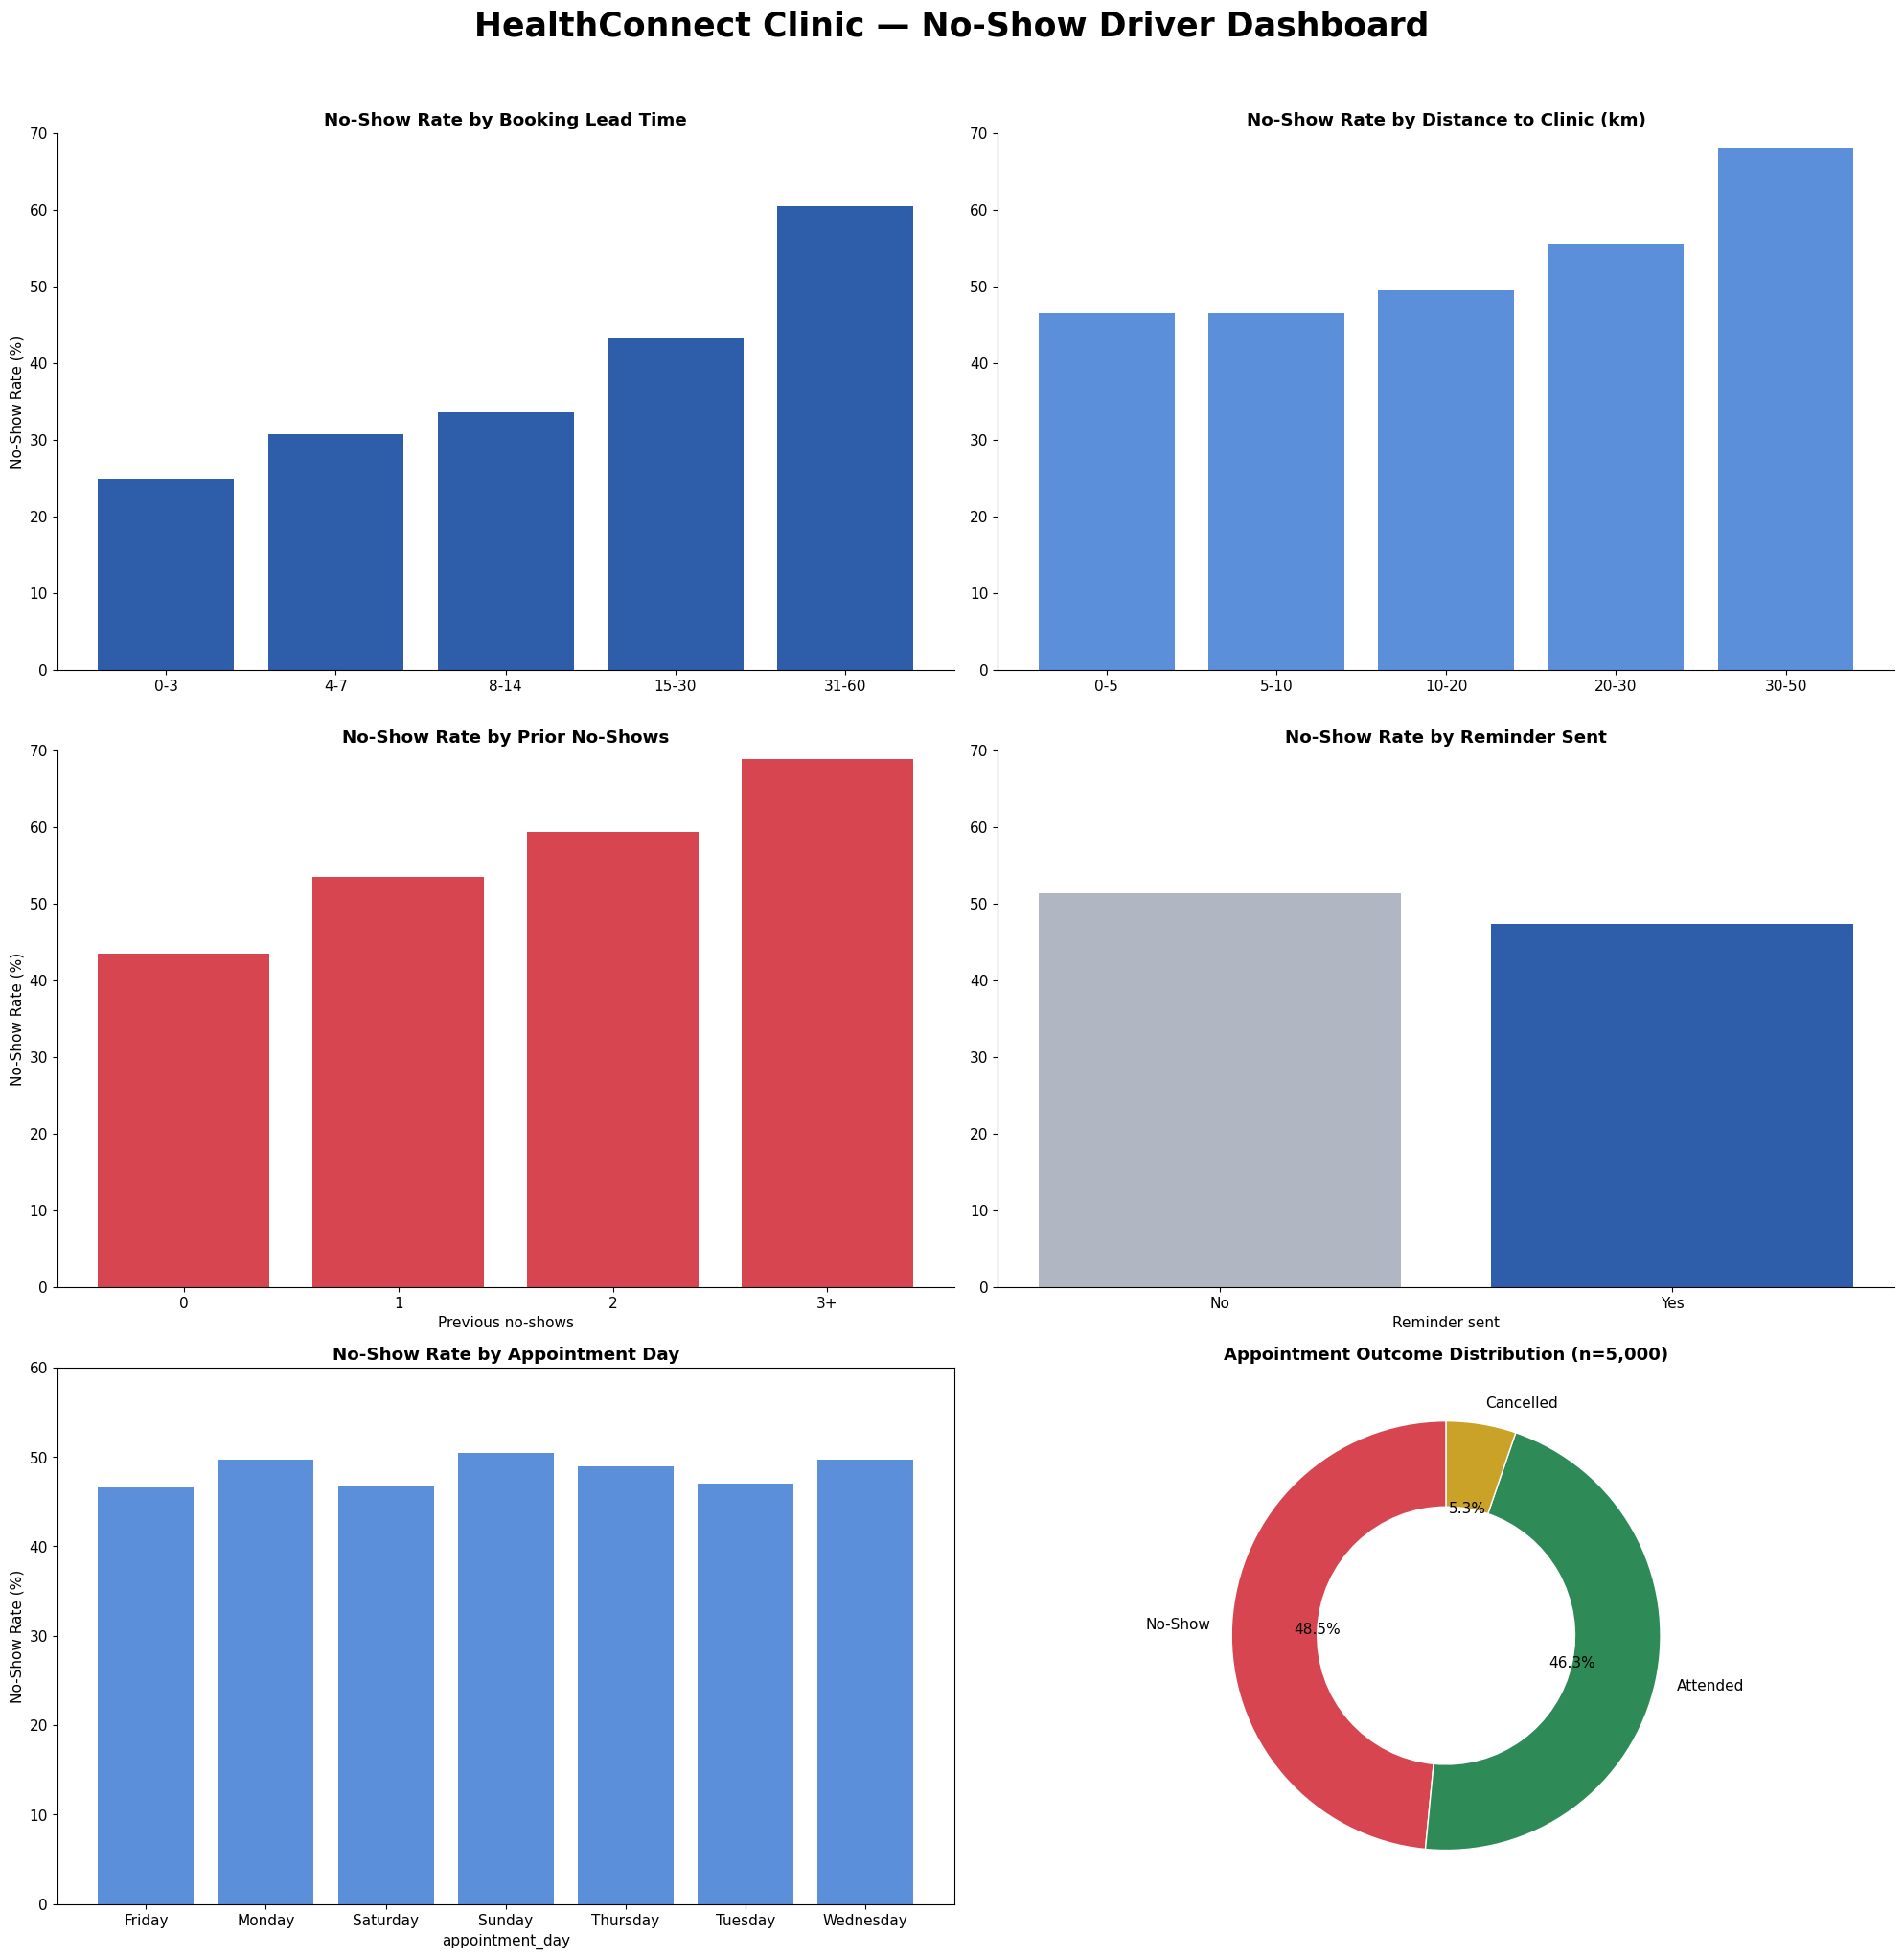

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
#Appointment Distribution
counts = df['appointment_outcome'].value_counts()
axes[2,1].set_title('Appointment Outcome Distribution (n=5,000)', fontsize=13, fontweight='bold')
axes[2,1].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90,
       wedgeprops=dict(width=0.4, edgecolor='white'))
axes[2,1].spines[['top','right']].set_visible(False)
# Lead time
r = df.groupby('lead_bucket', observed=True)['appointment_outcome'].apply(lambda x:(x=='No-Show').mean()*100)
axes[0,0].bar(r.index.astype(str), r.values, color=PRIMARY)
axes[0,0].set_title('No-Show Rate by Booking Lead Time', fontweight='bold')
axes[0,0].set_ylabel('No-Show Rate (%)'); axes[0,0].set_ylim(0,70)
axes[0,0].spines[['top','right']].set_visible(False)

# Distance
r = df.groupby('distance_bucket', observed=True)['appointment_outcome'].apply(lambda x:(x=='No-Show').mean()*100)
axes[0,1].bar(r.index.astype(str), r.values, color='#5B8FD9')
axes[0,1].set_title('No-Show Rate by Distance to Clinic (km)', fontweight='bold')
axes[0,1].set_ylim(0,70); axes[0,1].spines[['top','right']].set_visible(False)

# Prior no-shows
r = df.groupby('prev_noshow_bucket', observed=True)['appointment_outcome'].apply(lambda x:(x=='No-Show').mean()*100)
axes[1,0].bar(r.index.astype(str), r.values, color=NOSHOW_COLOR)
axes[1,0].set_title('No-Show Rate by Prior No-Shows', fontweight='bold')
axes[1,0].set_ylabel('No-Show Rate (%)'); axes[1,0].set_xlabel('Previous no-shows')
axes[1,0].set_ylim(0,70); axes[1,0].spines[['top','right']].set_visible(False)

# Reminder
r = df.groupby('reminder_sent')['appointment_outcome'].apply(lambda x:(x=='No-Show').mean()*100)
axes[1,1].bar(r.index, r.values, color=['#B0B7C3', PRIMARY])
axes[1,1].set_title('No-Show Rate by Reminder Sent', fontweight='bold')
axes[1,1].set_xlabel('Reminder sent'); axes[1,1].set_ylim(0,70)
axes[1,1].spines[['top','right']].set_visible(False)

#Appointment day
r = df.groupby('appointment_day',observed=True)['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100)
axes[2,0].bar(r.index.astype(str), r.values, color='#5B8FD9')
axes[2,0].set_title('No-Show Rate by Appointment Day', fontweight='bold')
axes[2,0].set_ylabel('No-Show Rate (%)'); axes[2,0].set_xlabel('appointment_day')
axes[2,0].set_ylim(0,60); ax.spines[['top','right']].set_visible(False)



fig.suptitle('HealthConnect Clinic — No-Show Driver Dashboard', fontsize=25, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig("healthconnect_chart.png", dpi=300, bbox_inches="tight")
plt.show()